In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# Load clean data
df = pd.read_csv('model/clean_data.csv')

print(f"✅ Dataset loaded!")
print(f"📊 Total rows: {len(df):,}")
print(f"📋 Columns: {list(df.columns)}")
df.head(3)

✅ Dataset loaded!
📊 Total rows: 71,537
📋 Columns: ['title', 'text', 'clean_title', 'clean_text', 'combined', 'label']


,title,text,clean_title,clean_text,combined,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,law enforcement high alert following threats c...,comment expected barack obama members fyf fuky...,law enforcement high alert following threats c...,1
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",unbelievable obama’s attorney general says cha...,demonstrators gathered last night exercising c...,unbelievable obama’s attorney general says cha...,1
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,bobby jindal raised hindu uses story christian...,dozen politically active pastors came private ...,bobby jindal raised hindu uses story christian...,0


In [3]:
# Drop any remaining nulls
df = df.dropna(subset=['combined', 'label'])

# Features and labels
X = df['combined']  # cleaned text
y = df['label']     # 0=Real, 1=Fake

print(f"✅ Features shape: {X.shape}")
print(f"✅ Labels shape: {y.shape}")
print(f"\nLabel distribution:")
print(y.value_counts())

✅ Features shape: (71537,)
✅ Labels shape: (71537,)

Label distribution:
label
1    36509
0    35028
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    stratify=y          # keep same ratio in both splits
)

print(f"✅ Data split complete!")
print(f"📊 Training samples: {len(X_train):,}")
print(f"📊 Testing samples:  {len(X_test):,}")

✅ Data split complete!
📊 Training samples: 57,229
📊 Testing samples:  14,308


In [5]:
print("⏳ Vectorizing text with TF-IDF...")

tfidf = TfidfVectorizer(
    max_features=50000,   # top 50k words
    ngram_range=(1, 2),   # single words + pairs
    min_df=2,             # ignore very rare words
    max_df=0.95           # ignore very common words
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✅ TF-IDF vectorization complete!")
print(f"📊 Training matrix shape: {X_train_tfidf.shape}")
print(f"📊 Testing matrix shape:  {X_test_tfidf.shape}")

⏳ Vectorizing text with TF-IDF...
✅ TF-IDF vectorization complete!
📊 Training matrix shape: (57229, 50000)
📊 Testing matrix shape:  (14308, 50000)


In [6]:
print("⏳ Training Logistic Regression model...")

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

model.fit(X_train_tfidf, y_train)

print("✅ Model trained successfully!")

⏳ Training Logistic Regression model...
✅ Model trained successfully!


In [7]:
# Make predictions
y_pred = model.predict(X_test_tfidf)

# Calculate scores
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("       MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"✅ Accuracy:  {accuracy * 100:.2f}%")
print(f"✅ F1 Score:  {f1 * 100:.2f}%")
print("=" * 50)

# Detailed report
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Real News', 'Fake News']))

       MODEL EVALUATION RESULTS
✅ Accuracy:  95.98%
✅ F1 Score:  95.98%

📊 Detailed Classification Report:
              precision    recall  f1-score   support

   Real News       0.96      0.95      0.96      7006
   Fake News       0.96      0.97      0.96      7302

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



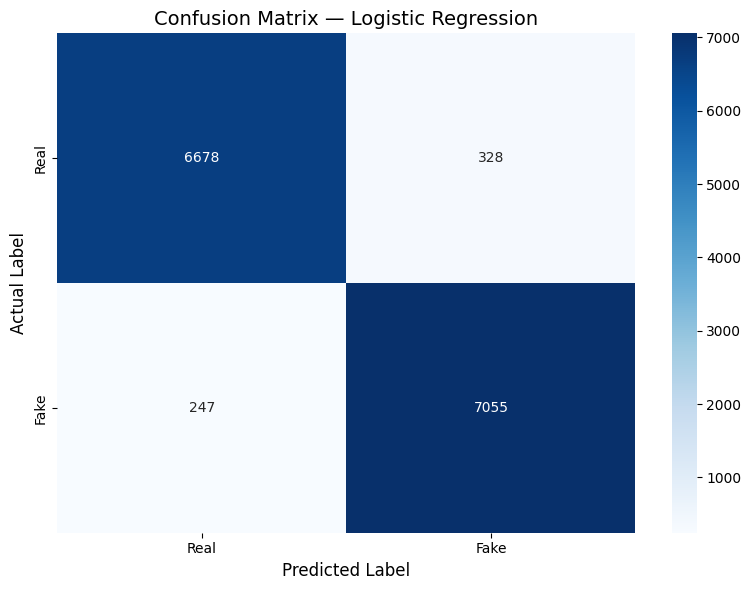

✅ Confusion matrix saved!


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('model/confusion_matrix.png')
plt.show()
print("✅ Confusion matrix saved!")

In [9]:
def predict_news(text):
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)[0]
    probability = model.predict_proba(text_tfidf)[0]
    confidence = max(probability) * 100

    label = "🔴 FAKE NEWS" if prediction == 1 else "🟢 REAL NEWS"
    print(f"Result: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 40)

# Test with examples
print("TEST 1:")
predict_news("NASA confirms water found on Mars surface in major scientific discovery")

print("TEST 2:")
predict_news("SHOCKING! Obama secretly born in Kenya, documents prove cover up conspiracy")

print("TEST 3:")
predict_news("Federal Reserve raises interest rates by 0.25 percent amid inflation concerns")

TEST 1:
Result: 🔴 FAKE NEWS
Confidence: 86.03%
----------------------------------------
TEST 2:
Result: 🔴 FAKE NEWS
Confidence: 97.07%
----------------------------------------
TEST 3:
Result: 🔴 FAKE NEWS
Confidence: 57.50%
----------------------------------------


In [10]:
os.makedirs('model', exist_ok=True)

# Save model
with open('model/baseline_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save TF-IDF vectorizer
with open('model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model saved successfully!")
print(f"📁 baseline_model.pkl → model/baseline_model.pkl")
print(f"📁 tfidf_vectorizer.pkl → model/tfidf_vectorizer.pkl")
print(f"\n🚀 Ready for Flask API integration!")

✅ Model saved successfully!
📁 baseline_model.pkl → model/baseline_model.pkl
📁 tfidf_vectorizer.pkl → model/tfidf_vectorizer.pkl

🚀 Ready for Flask API integration!


In [11]:
print("=" * 50)
print("     BASELINE MODEL — COMPLETE SUMMARY")
print("=" * 50)
print(f"✅ Algorithm:     Logistic Regression")
print(f"✅ Vectorizer:    TF-IDF (50,000 features)")
print(f"✅ Training size: {len(X_train):,} articles")
print(f"✅ Testing size:  {len(X_test):,} articles")
print(f"✅ Accuracy:      {accuracy * 100:.2f}%")
print(f"✅ F1 Score:      {f1 * 100:.2f}%")
print(f"✅ Model saved:   model/baseline_model.pkl")
print(f"✅ TF-IDF saved:  model/tfidf_vectorizer.pkl")
print("=" * 50)

     BASELINE MODEL — COMPLETE SUMMARY
✅ Algorithm:     Logistic Regression
✅ Vectorizer:    TF-IDF (50,000 features)
✅ Training size: 57,229 articles
✅ Testing size:  14,308 articles
✅ Accuracy:      95.98%
✅ F1 Score:      95.98%
✅ Model saved:   model/baseline_model.pkl
✅ TF-IDF saved:  model/tfidf_vectorizer.pkl
🚀 Ready for Day 10-12: BERT Model Training!
